In [1]:
import pandas as pd
import pickle

df = pd.read_pickle('../output/df_themen.pkl')
with open('../output/modelle.pkl', 'rb') as f:
    m = pickle.load(f)
with open('../output/vektoren.pkl', 'rb') as f:
    v = pickle.load(f)

ergebnisse_lda, ergebnisse_nmf, bestes_nmf_k = m['ergebnisse_lda'], m['ergebnisse_nmf'], m['bestes_nmf_k']
count_vectorizer, count_matrix = v['count_vectorizer'], v['count_matrix']

In [3]:
import pyLDAvis
import pyLDAvis.lda_model as lda_vis

bestes_lda_k = max(ergebnisse_lda, key=lambda k: ergebnisse_lda[k][1])
lda_final, _ = ergebnisse_lda[bestes_lda_k]

panel = lda_vis.prepare(lda_final, count_matrix, count_vectorizer, mds='mmds')
pyLDAvis.save_html(panel, '../output/lda_visualisierung.html')
print("Öffne die Datei output/lda_visualisierung.html im Browser, um das Ergebnis anzusehen.")

Öffne die Datei output/lda_visualisierung.html im Browser, um das Ergebnis anzusehen.


C:\Users\marti\Desktop\IU\2_B.Sc. BUSINESS INTELLIGENCE\PF_DLBDSEADA02_D_Projekt Data Analysis\2. Phase\nlp_beschwerdeanalyse\nlp_env\Lib\site-packages\sklearn\manifold\_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
C:\Users\marti\Desktop\IU\2_B.Sc. BUSINESS INTELLIGENCE\PF_DLBDSEADA02_D_Projekt Data Analysis\2. Phase\nlp_beschwerdeanalyse\nlp_env\Lib\site-packages\sklearn\manifold\_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


In [5]:
import pandas as pd
import pickle

df = pd.read_pickle('../output/df_themen.pkl')
with open('../output/modelle.pkl', 'rb') as f:
    m = pickle.load(f)
with open('../output/vektoren.pkl', 'rb') as f:
    v = pickle.load(f)

ergebnisse_lda, ergebnisse_nmf, bestes_nmf_k = m['ergebnisse_lda'], m['ergebnisse_nmf'], m['bestes_nmf_k']
tfidf, tfidf_matrix = v['tfidf'], v['tfidf_matrix']
count_vectorizer, count_matrix = v['count_vectorizer'], v['count_matrix']
print("Alles geladen.")

Alles geladen.


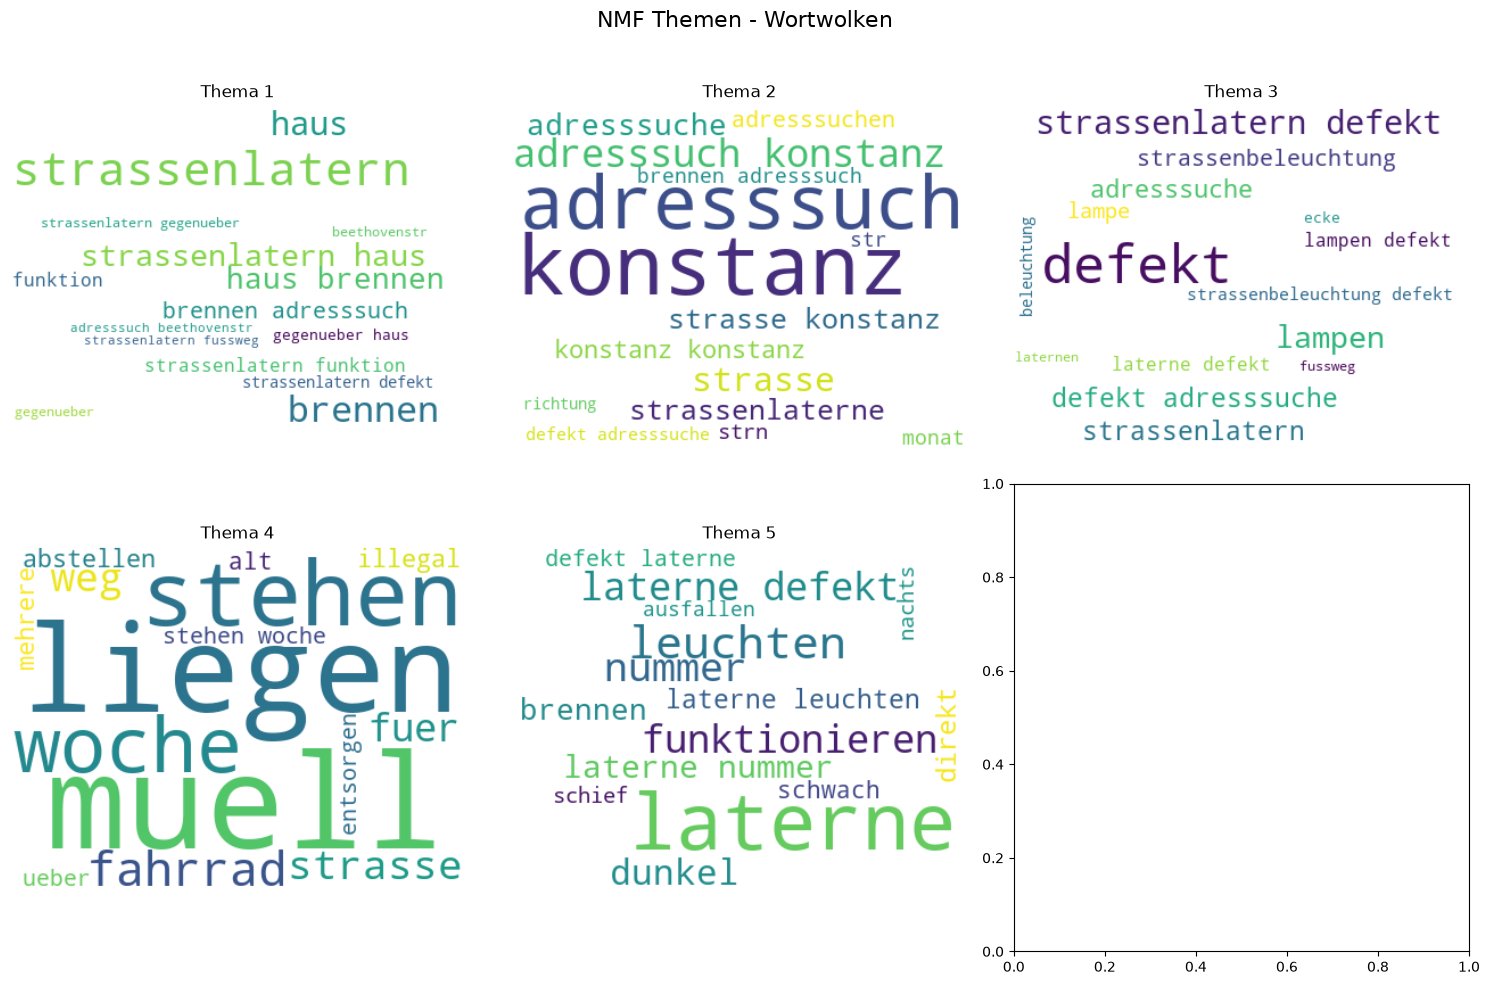

In [6]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

feature_names = tfidf.get_feature_names_out()
nmf_final, _ = ergebnisse_nmf[bestes_nmf_k]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('NMF Themen - Wortwolken', fontsize=16)
for idx, topic in enumerate(nmf_final.components_[:6]):
    top_idx = topic.argsort()[-15:][::-1]
    word_freq = {feature_names[i]: topic[i] for i in top_idx}
    wc = WordCloud(width=400, height=300, background_color='white', colormap='viridis').generate_from_frequencies(word_freq)
    ax = axes[idx // 3, idx % 3]
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Thema {idx + 1}')
    ax.axis('off')
plt.tight_layout()
plt.savefig('../output/nmf_wordclouds.png', dpi=300, bbox_inches='tight')
plt.show()

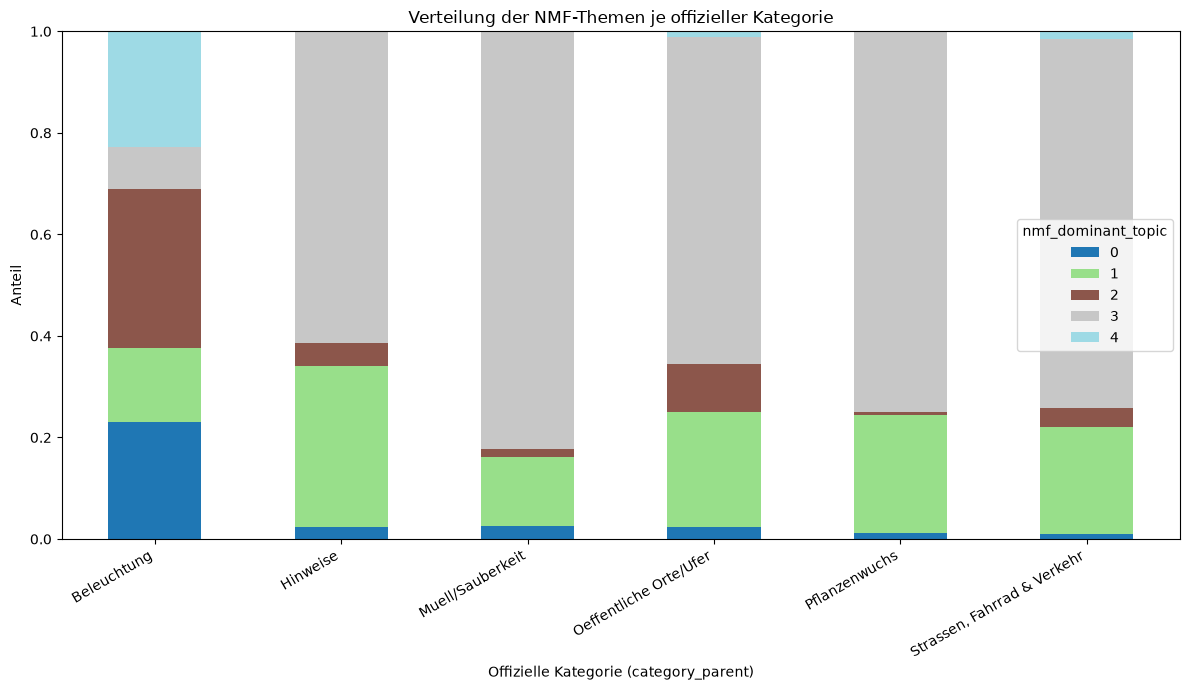

In [7]:
import seaborn as sns

kreuztabelle = pd.crosstab(df['category_parent'], df['nmf_dominant_topic'])
kreuztabelle_prozent = kreuztabelle.div(kreuztabelle.sum(axis=1), axis=0)

kreuztabelle_prozent.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab20')
plt.title('Verteilung der NMF-Themen je offizieller Kategorie')
plt.ylabel('Anteil')
plt.xlabel('Offizielle Kategorie (category_parent)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../output/kategorie_vergleich.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
bestes_lda_k = max(ergebnisse_lda, key=lambda k: ergebnisse_lda[k][1])
print(f"LDA: bestes k={bestes_lda_k} mit c_v={ergebnisse_lda[bestes_lda_k][1]:.4f}")
print(f"NMF: bestes k={bestes_nmf_k} mit c_v={ergebnisse_nmf[bestes_nmf_k][1]:.4f}")

LDA: bestes k=8 mit c_v=0.3984
NMF: bestes k=5 mit c_v=0.4541
